# Análise Exploratória de Dados de Consumo e Potência do Sistema Elétrico Brasileiro

> Dados obtidos das fontes oficiais da **ONS** (Operador Nacional do Sistema Elétrico).
> O objetivo é observar a **curva de demanda e carga** do sistema no ano de **2025**.

---

## 1. Carregamento dos Dados

Iniciamos carregando os dados no **Python** e utilizando a biblioteca **pandas** para organizar o dataset.

In [20]:
import pandas as pd
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

In [21]:
df = pd.read_csv('CURVA_CARGA_2025.csv', sep=';')
df = df.rename(columns={"id_subsistema":"Regioes S","nom_subsistema":"Regioes ","Data":"din_instante","val_cargaenergiahomwmed":"Carga"})
print(df.head())
print("Formato:", df.shape)
print("header:\n", df[:4])

#Slice por região, se quiser olhar
#print(data_array[np.argwhere(data_array == 'N')[:,0]])


  Regioes S  Regioes          din_instante      Carga
0         N     NORTE  2025-01-01 00:00:00   7097.751
1        NE  NORDESTE  2025-01-01 00:00:00  12251.182
2         S       SUL  2025-01-01 00:00:00  10554.603
3        SE   SUDESTE  2025-01-01 00:00:00  35374.033
4         N     NORTE  2025-01-01 01:00:00   7053.337
Formato: (35040, 4)
header:
   Regioes S  Regioes          din_instante      Carga
0         N     NORTE  2025-01-01 00:00:00   7097.751
1        NE  NORDESTE  2025-01-01 00:00:00  12251.182
2         S       SUL  2025-01-01 00:00:00  10554.603
3        SE   SUDESTE  2025-01-01 00:00:00  35374.033


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Data frame 1 CURVA_CARGA_2025.csv

dfo = pd.read_csv('CURVA_CARGA_2025.csv', sep=';')
dfo = dfo.rename(columns={"id_subsistema":"Regioes","nom_subsistema":"SUBMERCADO","din_instante":"Data","val_cargaenergiahomwmed":"Carga"})
dfo['Data'] = pd.to_datetime(dfo['Data'])
dfo["Mes"] = dfo["Data"].dt.month
dfo["DIA"] = dfo["Data"].dt.day
dfo["HORA"] = dfo["Data"].dt.hour
dfo.info()
dfo.describe()
dfo

#Data frame 2 pld_horario_2025.csv

dfo2 = pd.read_csv('pld_horario_2025.csv', sep=';')
dfo2.info()
dfo2.describe()
dfo2

#Data frame Final

df = pd.merge(dfo, dfo2, on=['SUBMERCADO', 'DIA', 'HORA'], how='inner')

#Add uma nova coluna

df['Custos_Milhoes'] = (df['Carga'] * df['PLD_HORA']) / 1e6
df["Carga_MW"] = df["Carga"] / 1e6
data_array = df.to_numpy()

print(df)



<class 'pandas.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Regioes     35040 non-null  str           
 1   SUBMERCADO  35040 non-null  str           
 2   Data        35040 non-null  datetime64[us]
 3   Carga       35040 non-null  float64       
 4   Mes         35040 non-null  int32         
 5   DIA         35040 non-null  int32         
 6   HORA        35040 non-null  int32         
dtypes: datetime64[us](1), float64(1), int32(3), str(2)
memory usage: 1.5 MB
<class 'pandas.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   MES_REFERENCIA           35040 non-null  int64  
 1   SUBMERCADO               35040 non-null  str    
 2   PERIODO_COMERCIALIZACAO  35040 non-null  int64  
 3   DIA                   

In [23]:
df["Carga_KW"] = df["Carga"] / 1e3
df



,Regioes,SUBMERCADO,Data,Carga,Mes,DIA,HORA,MES_REFERENCIA,PERIODO_COMERCIALIZACAO,PLD_HORA,Custos_Milhoes,Carga_MW,Carga_KW
0,N,NORTE,2025-01-01 00:00:00,7097.751,1,1,0,202512,1,329.36,2.337715,0.007098,7.097751
1,N,NORTE,2025-01-01 00:00:00,7097.751,1,1,0,202511,1,340.65,2.417849,0.007098,7.097751
2,N,NORTE,2025-01-01 00:00:00,7097.751,1,1,0,202510,1,297.09,2.108671,0.007098,7.097751
3,N,NORTE,2025-01-01 00:00:00,7097.751,1,1,0,202509,1,295.39,2.096605,0.007098,7.097751
4,N,NORTE,2025-01-01 00:00:00,7097.751,1,1,0,202508,1,306.75,2.177235,0.007098,7.097751
...,...,...,...,...,...,...,...,...,...,...,...,...,...
415003,SE,SUDESTE,2025-12-31 23:00:00,42418.294,12,31,23,202508,744,304.88,12.932489,0.042418,42.418294
415004,SE,SUDESTE,2025-12-31 23:00:00,42418.294,12,31,23,202507,744,308.05,13.066955,0.042418,42.418294
415005,SE,SUDESTE,2025-12-31 23:00:00,42418.294,12,31,23,202501,744,59.07,2.505649,0.042418,42.418294
415006,SE,SUDESTE,2025-12-31 23:00:00,42418.294,12,31,23,202503,744,285.19,12.097273,0.042418,42.418294


In [24]:
# 1. Definir o tamanho da figura e um tema limpo
plt.figure(figsize=(12, 8))
sns.set_theme(style="white")

# 2. Criar o Heatmap com melhorias estéticas
ax = sns.heatmap(
    pivot,
    annot=True,          # Mantém os números
    fmt=".1f",           # Formata para 1 casa decimal (mais limpo)
    cmap="YlOrRd",       # Paleta Amarelo-Laranja-Vermelho (ideal para custos)
    linewidths=.5,       # Adiciona uma linha fina separando os quadrados
    cbar_kws={'label': 'Milhões de Reais'} # Título da barra lateral
)

# 3. Melhorar Títulos e Eixos
plt.title("Distribuição de Custos por Submercado e Hora", fontsize=16, pad=20, fontweight='bold')
plt.xlabel("Submercado", fontsize=12)
plt.ylabel("Hora do Dia", fontsize=12)

# 4. Ajustar rotação dos labels para não sobrepor
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

NameError: name 'pivot' is not defined

<Figure size 1200x800 with 0 Axes>

> **Lembre-se:** para todas as análises, devemos escolher a métrica mais adequada ao contexto —
> seja **média**, **mediana** ou valor **líquido**.
> A ONS disponibiliza um repositório gigantesco em: https://registry.opendata.aws/ons-opendata-portal/?utm

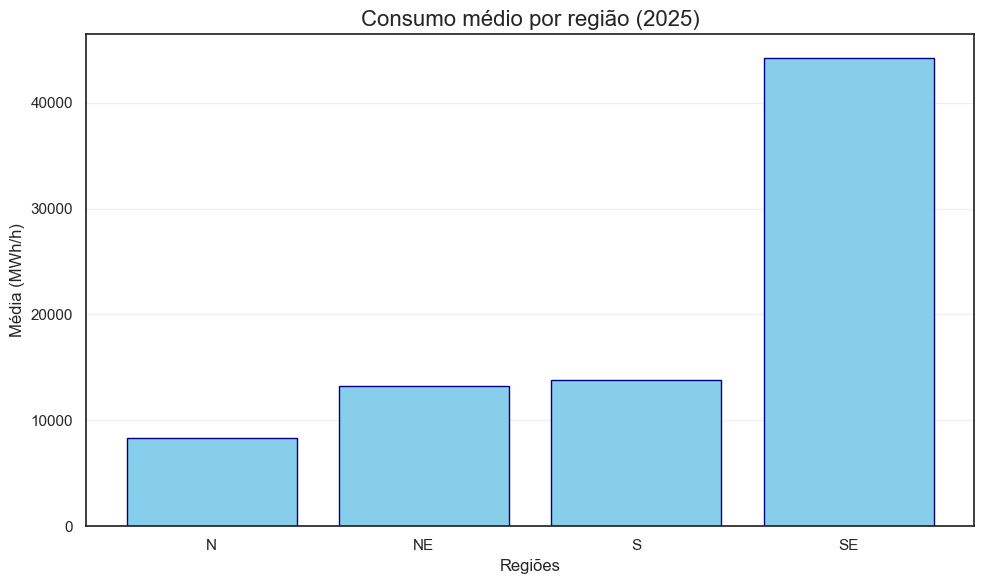

<Figure size 640x480 with 0 Axes>

In [ ]:
media = []
regioes = np.unique(data_array[:, 0])  # pega regiões únicas corretamente

for regiao in regioes:
    filtro = data_array[:, 0] == regiao   # filtra só a coluna de regiões
    valores = data_array[filtro][:, 3].astype(float)  # pega consumo
    media.append(np.mean(valores))

plt.figure(figsize=(10, 6))
plt.bar(regioes, media, color='skyblue', edgecolor='navy')

plt.title('Consumo médio por região (2025)', fontsize=16)
plt.xlabel('Regiões', fontsize=12)
plt.ylabel('Média (MWh/h)', fontsize=12)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
#plt.savefig('media_por_regiao.png')

### 2.1 Potência Líquida Consumida por Região (2025)

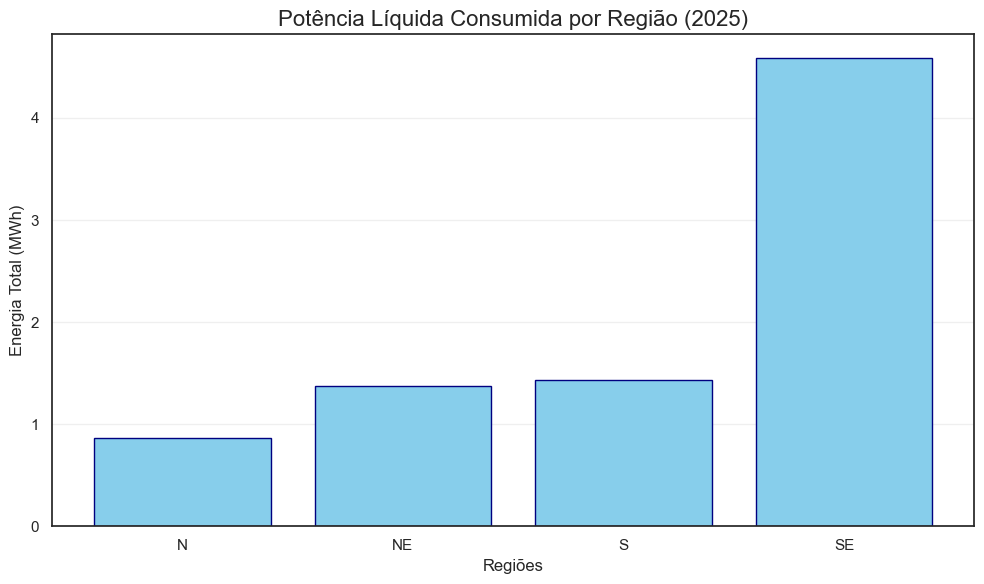

In [25]:
soma = []
regioes = np.unique(data_array[:, 0])  # regiões únicas

for regiao in regioes:
    filtro = data_array[:, 0] == regiao
    valores = data_array[filtro][:, 3].astype(float)

    soma.append(np.sum(valores) / 1e9)  # convertendo para MWh

# gráfico fora do loop
plt.figure(figsize=(10, 6))
plt.bar(regioes, soma, color='skyblue', edgecolor='navy')

plt.title('Potência Líquida Consumida por Região (2025)', fontsize=16)
plt.xlabel('Regiões', fontsize=12)
plt.ylabel('Energia Total (MWh)', fontsize=12)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 2.2 Potência Média Mensal por Região

Analisar apenas a potência média e líquida ao longo do ano limita algumas análises relevantes.
Para aprofundar a investigação,
avaliamos a **potência média consumida mês a mês**, com o objetivo de identificar
qual período do ano apresenta a **maior carga**, e possíveis tendências de consumo ao decorrer do ano.

[ 1  2  3  4  5  6  7  8  9 10 11 12]


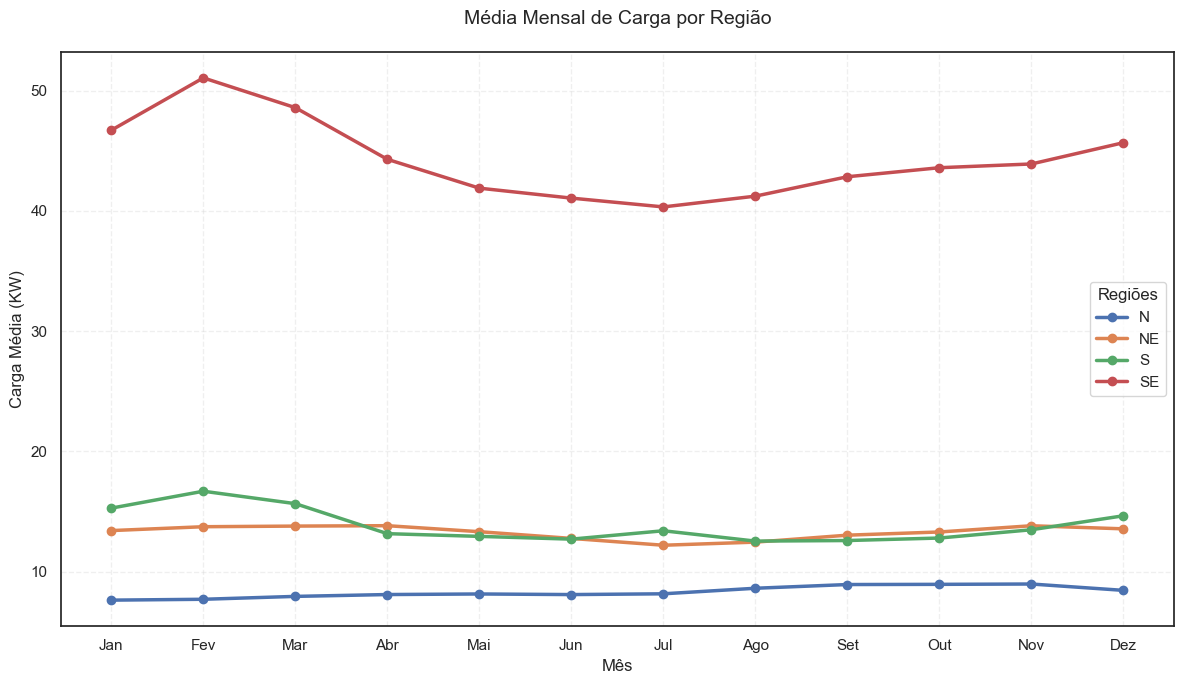

In [26]:
regiões = []
meses = np.array(range(1,13))
print(meses)
df["Data"]= pd.to_datetime(df["Data"])
df["Mes"] = df["Data"].dt.month

meses = df.groupby(["Regioes","Mes"])["Carga_KW"].mean().reset_index()

# Plot das 4 curvas no mesmo gráfico
plt.figure(figsize=(12, 7))

regioes_unicas = df["Regioes"].unique()   # pega as 4 regiões automaticamente

for regiao in regioes_unicas:
    dados_regiao = meses[meses["Regioes"] == regiao]
    plt.plot(dados_regiao["Mes"],
             dados_regiao["Carga_KW"],
             marker='o',
             linewidth=2.5,
             label=regiao.strip())   # .strip() para remover espaços extras no nome

plt.title("Média Mensal de Carga por Região", fontsize=14, pad=20)
plt.xlabel("Mês", fontsize=12)
plt.ylabel("Carga Média (KW)", fontsize=12)
plt.xticks(range(1, 13),
           ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
            'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])

plt.legend(title="Regiões", fontsize=11, title_fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

plt.show()

### 2.3 Potência Média por Hora do Dia — Região Sul-Sudeste

A mesma análise pode ser realizada em escala horária, já que o perfil de consumo da população
varia significativamente ao longo do dia.
Vamos observar a **potência média consumida hora a hora**.

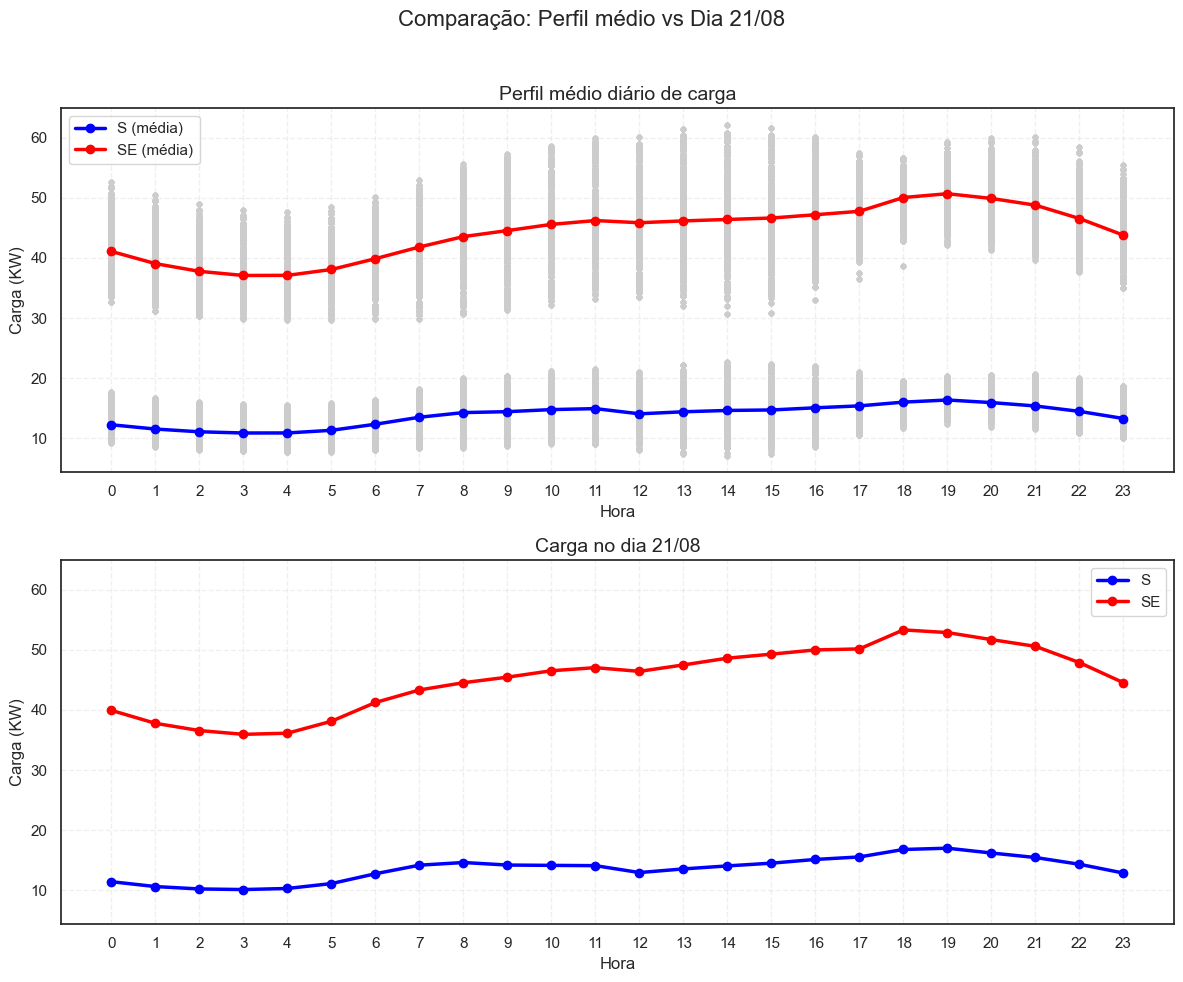

In [27]:
# =========================
# PREPARAÇÃO DOS DADOS
# =========================

# Garantir cópia segura
df_filtrado = df[df["Regioes"].isin(["S", "SE"])].copy()

# Converter data corretamente
df_filtrado["Data"] = pd.to_datetime(df_filtrado["Data"], dayfirst=True)



# =========================
# CRIAÇÃO DOS GRÁFICOS
# =========================

mosaico = "AA;BB"
fig = plt.figure(figsize=(12,10))
axs = fig.subplot_mosaic(mosaico)

regioes = ["S", "SE"]
cores = {"S": "blue", "SE": "red"}

# =========================
# GRÁFICO 1 - MÉDIA ANUAL
# =========================

# =========================
# GRÁFICO 1 - MÉDIA + DISPERSÃO
# =========================

horas_media = (
    df_filtrado
    .groupby(["Regioes", "HORA"])["Carga_KW"]
    .mean()
    .reset_index()
)

for regiao in regioes:

    # dados reais (dispersão)
    dados_raw = df_filtrado[df_filtrado["Regioes"] == regiao]

    axs['A'].scatter(
        dados_raw["HORA"],
        dados_raw["Carga_KW"],
        alpha=0.4,
        s=10,
        color=(0.8, 0.8, 0.8)
    )

    # média (linha)
    dados_media = horas_media[horas_media["Regioes"] == regiao].sort_values("HORA")

    axs['A'].plot(
        dados_media["HORA"],
        dados_media["Carga_KW"],
        marker='o',
        linewidth=2.5,
        label=f"{regiao} (média)",
        color=cores[regiao]
    )
axs['A'].set_title("Perfil médio diário de carga", fontsize=14)
axs['A'].set_xlabel("Hora")
axs['A'].set_ylabel("Carga (KW)")
axs['A'].set_xticks(range(24))
axs['A'].grid(True, alpha=0.3, linestyle='--')
axs['A'].legend()

# =========================
# GRÁFICO 2 - DIA 21/08
# =========================
# Filtrar dia específico (21/08)
df_filtrado_FData = df_filtrado[
    df_filtrado["Data"].dt.date == pd.to_datetime("2025-08-21").date()

]
horas_dia = df_filtrado_FData.groupby(["Regioes", "HORA"])["Carga_KW"].mean().reset_index()

for regiao in regioes:
    dados = horas_dia[horas_dia["Regioes"] == regiao].sort_values("HORA")

    axs['B'].plot(
        dados["HORA"],
        dados["Carga_KW"],
        marker='o',
        linewidth=2.5,
        label=regiao,
        color=cores[regiao]
    )

axs['B'].set_title("Carga no dia 21/08", fontsize=14)
axs['B'].set_xlabel("Hora")
axs['B'].set_ylabel("Carga (KW)")
axs['B'].set_xticks(range(24))
axs['B'].grid(True, alpha=0.3, linestyle='--')
axs['B'].legend()

# =========================
# AJUSTE FINAL
# =========================

# Igualar escala dos gráficos (comparação justa)
ymin = min(axs['A'].get_ylim()[0], axs['B'].get_ylim()[0])
ymax = max(axs['A'].get_ylim()[1], axs['B'].get_ylim()[1])

axs['A'].set_ylim(ymin, ymax)
axs['B'].set_ylim(ymin, ymax)

fig.suptitle("Comparação: Perfil médio vs Dia 21/08", fontsize=16)

fig.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

### 2.4 Potência Líquida Consumida por Estação do Ano e Região

O Brasil apresenta variações térmicas consideráveis ao longo do ano, o que influencia
diretamente o perfil de consumo energético. Regiões específicas tendem a seguir
tendências de carga associadas às estações — com picos distintos no **verão** e no **inverno**.

Para capturar esse comportamento, dividimos o ano em suas **quatro estações**
e avaliamos a **potência líquida consumida por região**.

É interessante plotar um gráfico linha, separando por região e com cada linha representando uma época do ano.

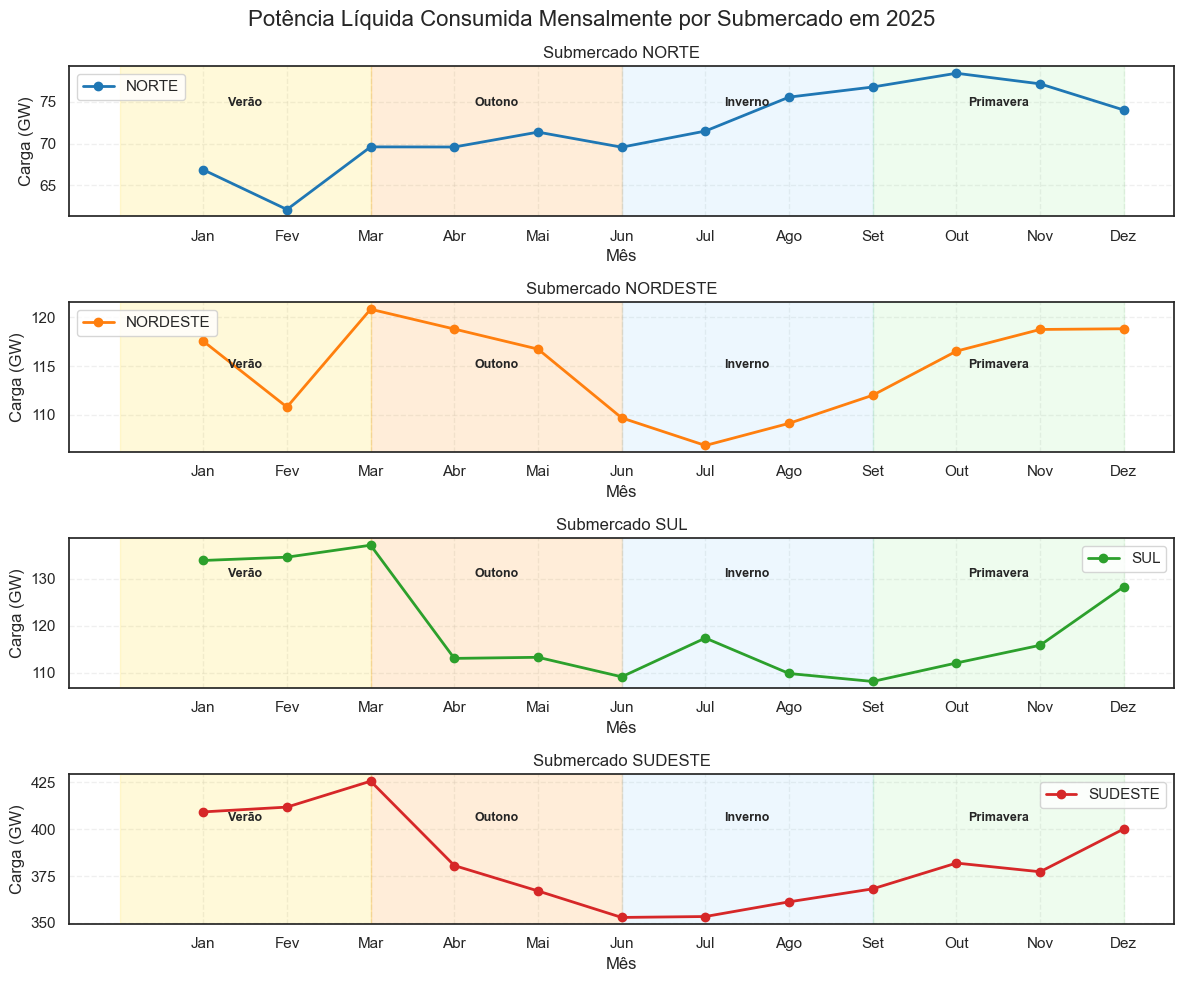

In [28]:
import matplotlib.pyplot as plt

# =========================
# DADOS
# =========================

meses = df.groupby(["SUBMERCADO", "Mes"])["Carga_KW"].sum().reset_index()

# =========================
# MOSAICO
# =========================

mosaico = "AA;BB;CC;DD"
fig = plt.figure(figsize=(12,10))
axs = fig.subplot_mosaic(mosaico)

regioes_unicas = df["SUBMERCADO"].unique()
chaves = ["A", "B", "C", "D"]
mapa = dict(zip(regioes_unicas, chaves))

cores = dict(zip(regioes_unicas, plt.cm.tab10.colors))

# =========================
# ESTAÇÕES CORRETAS (Brasil)
# =========================

estacoes = [
    (0, 3, "Verão"),
    (3, 6, "Outono"),
    (6, 9, "Inverno"),
    (9, 12, "Primavera")
]

# cores só para estações (se quiser diferenciar)
cores_estacoes = {
    "Verão": "#FFD700",
    "Outono": "#FF8C00",
    "Inverno": "#87CEFA",
    "Primavera": "#90EE90"
}

# =========================
# LOOP
# =========================

for regiao in regioes_unicas:

    dados = meses[meses["SUBMERCADO"] == regiao].sort_values("Mes")
    dados["Carga_GW"] = dados["Carga_KW"] / 1e3
    ax = axs[mapa[regiao]]

    ymax = dados["Carga_GW"].max()

    # estações
    for inicio, fim, nome in estacoes:

        ax.axvspan(inicio, fim, color=cores_estacoes[nome], alpha=0.15)

        ax.text(
            (inicio + fim) / 2,
            ymax * 0.95,
            nome,
            ha="center",
            fontsize=9,
            weight="bold"
        )

    # linha principal
    ax.plot(
        dados["Mes"],
        dados["Carga_GW"],
        marker="o",
        linewidth=2,
        label=regiao,
        color=cores[regiao]
    )

    ax.set_title(f"Submercado {regiao}")
    ax.set_xlabel("Mês")
    ax.set_ylabel("Carga (GW)")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels([
        'Jan','Fev','Mar','Abr','Mai','Jun',
        'Jul','Ago','Set','Out','Nov','Dez'
    ])

    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend()

# =========================
# FINAL
# =========================

fig.suptitle("Potência Líquida Consumida Mensalmente por Submercado em 2025", fontsize=16)
fig.tight_layout()
plt.show()

## 3 Análise Econômica

Além das análises de carga, é possível explorar os dados pela ótica do **preço de energia**.
Ao cruzar dois datasets — **preço de energia** e **consumo** — podemos extrair
insights relevantes sobre a relação entre custo e demanda no sistema elétrico brasileiro.

Utilizaremos os dados do PLD, **Horário** de 2025, disponível em: https://pda-download.ccee.org.br/korJMXwpSLGyVlpRMQWduA/content



### 3.1 Carregamento e Filtragem de dados

Carregamos e filtramos todos os dados indesejáveis


### 3.2 Curva de PLD Horário média por mês

É interessante investigar o preço médio do PLD horário mensal afim de procurar correlações com o consumo de energia.

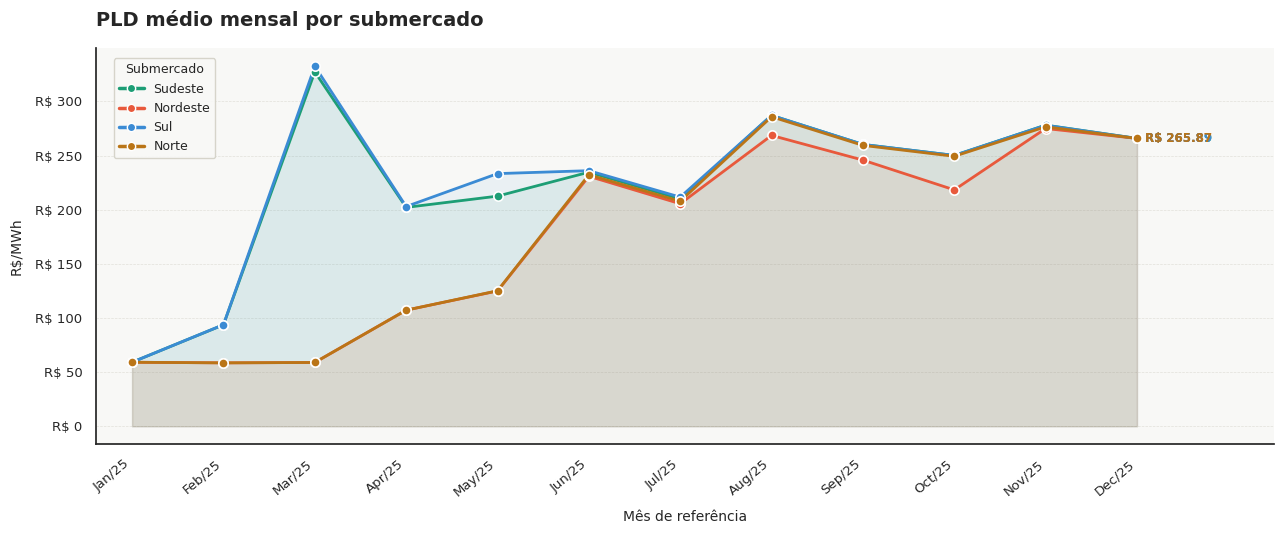

In [ ]:
df2 = pd.read_csv('pld_horario_2025.csv', sep=';')
#print(df2.head())
df2["MES_REFERENCIA"] = df2["MES_REFERENCIA"].astype(str)
df2["PLD_HORA"]       = pd.to_numeric(df2["PLD_HORA"], errors="coerce")

# ── 2. Média mensal por submercado ────────────────────────────────────────────
media_mensal = (
    df2
    .groupby(["MES_REFERENCIA", "SUBMERCADO"])["PLD_HORA"]
    .mean()
    .reset_index()
    .rename(columns={"PLD_HORA": "PLD_MEDIO"})
)

# ── 3. Converter YYYYMM → datetime e criar rótulo "Mmm/AA" ───────────────────
media_mensal["DATA"] = pd.to_datetime(
    media_mensal["MES_REFERENCIA"], format="%Y%m"
)
media_mensal["ROTULO"] = media_mensal["DATA"].dt.strftime("%b/%y").str.capitalize()

# Ordenar cronologicamente
media_mensal = media_mensal.sort_values("DATA")

# Meses únicos ordenados (para o eixo X)
meses_ord  = media_mensal.drop_duplicates("DATA").sort_values("DATA")
rotulos    = meses_ord["ROTULO"].tolist()
x_pos      = np.arange(len(rotulos))          # 0, 1, 2 …

# ── 4. Estilo ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.facecolor":    "#F8F8F6",
    "figure.facecolor":  "#FFFFFF",
    "grid.color":        "#D3D1C7",
    "grid.linewidth":    0.5,
})

SUBMERCADOS = ["SUDESTE", "NORDESTE", "SUL", "NORTE"]
CORES = {
    "SUDESTE":  "#1D9E75",
    "NORDESTE": "#E8593C",
    "SUL":      "#3B8BD4",
    "NORTE":    "#BA7517",
}

# ── 5. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5.5))

for sub in SUBMERCADOS:
    dados = (
        media_mensal[media_mensal["SUBMERCADO"] == sub]
        .set_index("ROTULO")
        .reindex(rotulos)           # garante a ordem correta
    )
    cor = CORES[sub]

    # Linha principal
    ax.plot(
        x_pos, dados["PLD_MEDIO"],
        color=cor, linewidth=2, zorder=3,
    )
    # Área preenchida sob a linha
    ax.fill_between(
        x_pos, dados["PLD_MEDIO"],
        alpha=0.07, color=cor, zorder=2,
    )
    # Marcadores
    ax.scatter(
        x_pos, dados["PLD_MEDIO"],
        color=cor, s=45, zorder=4,
        edgecolors="white", linewidths=1.2,
    )
    # Rótulo de valor no último ponto
    ultimo_val = dados["PLD_MEDIO"].dropna()
    if not ultimo_val.empty:
        ix = ultimo_val.index.get_loc(ultimo_val.index[-1])
        ax.annotate(
            f"R$ {ultimo_val.iloc[-1]:.2f}",
            xy=(len(rotulos) - 1, ultimo_val.iloc[-1]),
            xytext=(6, 0), textcoords="offset points",
            color=cor, fontsize=8.5, va="center", fontweight="bold",
        )

# ── 6. Eixos e grade ──────────────────────────────────────────────────────────
ax.set_xticks(x_pos)
ax.set_xticklabels(rotulos, rotation=40, ha="right", fontsize=9.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"R$ {v:,.0f}"))
ax.tick_params(axis="y", labelsize=9.5)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.set_xlim(-0.4, len(rotulos) - 1 + 1.5)   # espaço p/ rótulos do último ponto

# ── 7. Títulos ────────────────────────────────────────────────────────────────
ax.set_title(
    "PLD médio mensal por submercado",
    fontsize=14, fontweight="bold", pad=16, loc="left",
)
ax.set_xlabel("Mês de referência", fontsize=10, labelpad=8)
ax.set_ylabel("R$/MWh", fontsize=10, labelpad=8)

# ── 8. Legenda customizada ────────────────────────────────────────────────────
handles = [
    Line2D([0], [0], color=CORES[s], linewidth=2.5,
           marker="o", markersize=6,
           markerfacecolor=CORES[s], markeredgecolor="white", markeredgewidth=1,
           label=s.capitalize())
    for s in SUBMERCADOS
]
ax.legend(
    handles=handles,
    title="Submercado", title_fontsize=9,
    fontsize=9, framealpha=0.92,
    loc="upper left", bbox_to_anchor=(0.01, 0.99),
    frameon=True, edgecolor="#D3D1C7",
)

plt.tight_layout()
#plt.savefig("pld_mensal.png", dpi=150, bbox_inches="tight")
plt.show()



### 3.3 PLD Horário Por região

Agora podemos observar o preço da energia horário por região, afim de buscar correlações de consumo horário.


In [30]:
#CODE

## 4 Análise de correlação Preço/Consumo
Podemos agora analisar a correlação entre o preço e o consumo de energia.


### 4.1 Cálculo de coeficiente de correlação.

In [31]:
correlacao = df["Carga"].corr(df["PLD_HORA"])
print(correlacao)

0.11992080878734711


### 4.2 Matriz de correlação

Pegamos um dia aleatório e plotamos um Heatmap contendo preço de energia e consumo de energia por hora.

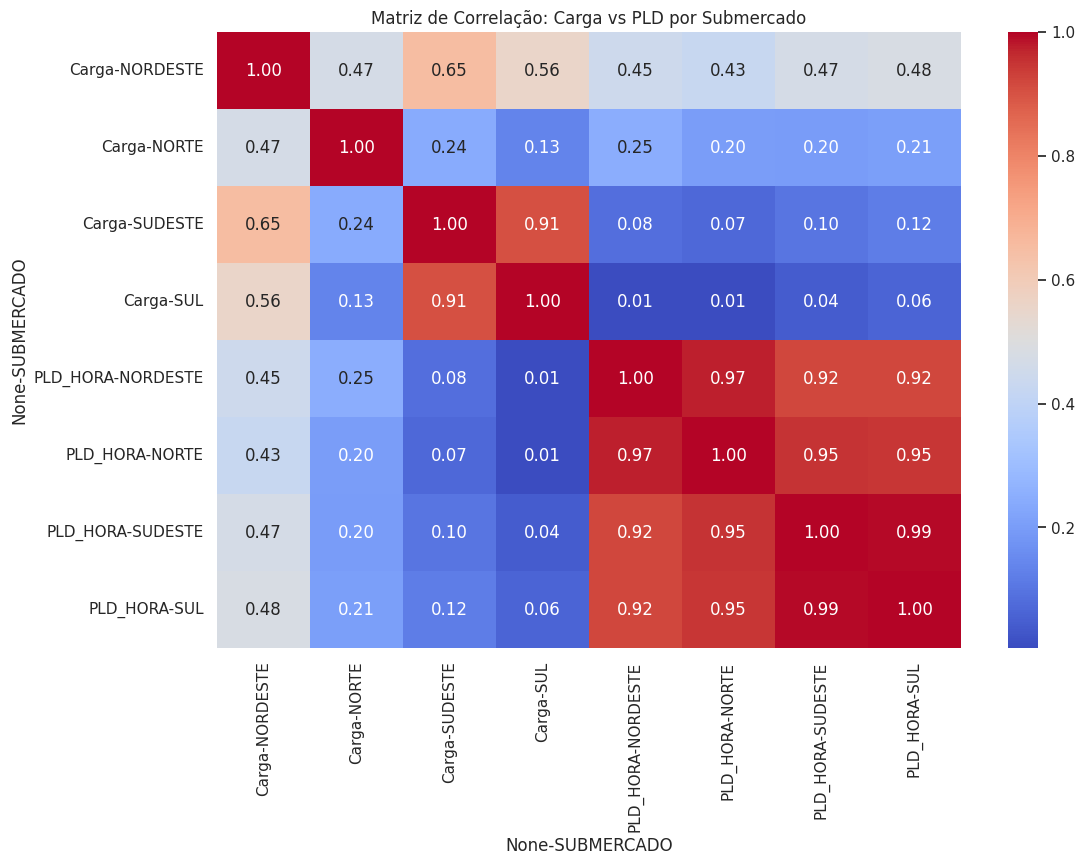

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Supondo que seu df se chame 'df_energia'
# 1. Pivotar os dados para ter Carga e PLD por submercado em colunas separadas
df_pivot = df.pivot_table(
    index=['Data', 'HORA'], 
    columns='SUBMERCADO', 
    values=['Carga', 'PLD_HORA']
)

# 2. Calcular a matriz de correlação
corr_matrix = df_pivot.corr()

# 3. Plotar o Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação: Carga vs PLD por Submercado')
plt.show()

A correlação entre Carga e PLD foi aproximadamente 0,12, indicando uma relação positiva muito fraca.

Na prática, isso significa que a carga quase não explica o comportamento do preço. O PLD depende de vários outros fatores (como hidrologia e despacho térmico), por isso não há uma relação linear clara entre as duas variáveis.

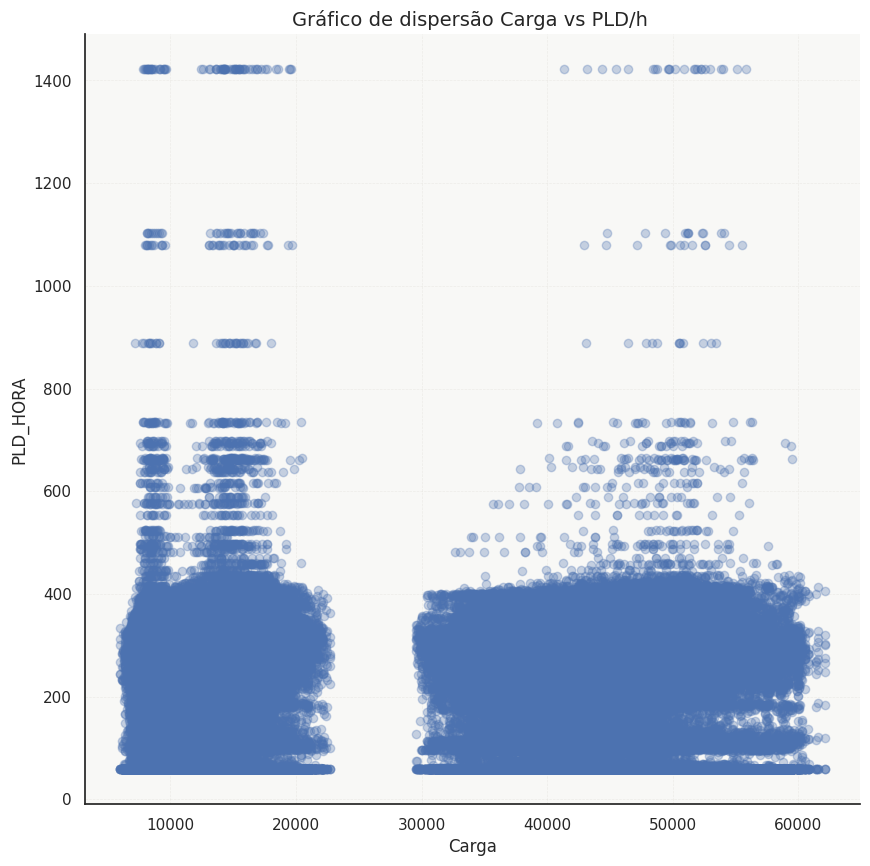

In [33]:
mosaico = "A"
fig = plt.figure(figsize=(10,10))
axs = fig.subplot_mosaic(mosaico)
axs['A'].scatter(df["Carga"], df["PLD_HORA"], alpha=0.3)
axs['A'].set_title("Gráfico de dispersão Carga vs PLD/h ", fontsize=14)
axs['A'].set_xlabel("Carga")
axs['A'].set_ylabel("PLD_HORA")
axs['A'].grid(True, alpha=0.3, linestyle='--')
plt.show()

O gráfico de dispersão reforça o resultado da correlação baixa. Os pontos aparecem muito espalhados, sem formar uma linha ou tendência clara de crescimento. Para um mesmo valor de Carga, existem diversos valores diferentes de PLD, o que mostra grande variabilidade.

Além disso, observa-se a formação de agrupamentos de pontos (blocos) ao longo do eixo da carga, indicando que os dados podem estar misturando diferentes condições ou períodos. Dentro desses grupos, não há inclinação evidente que indique relação linear.

Assim, o gráfico confirma que não existe um padrão consistente entre as variáveis, evidenciando que a carga, sozinha, não explica bem o comportamento do PLD.

### 5. Estatistica descritiva


### 5.1 Media, Moda e Mediana de consumo e preço em cada região

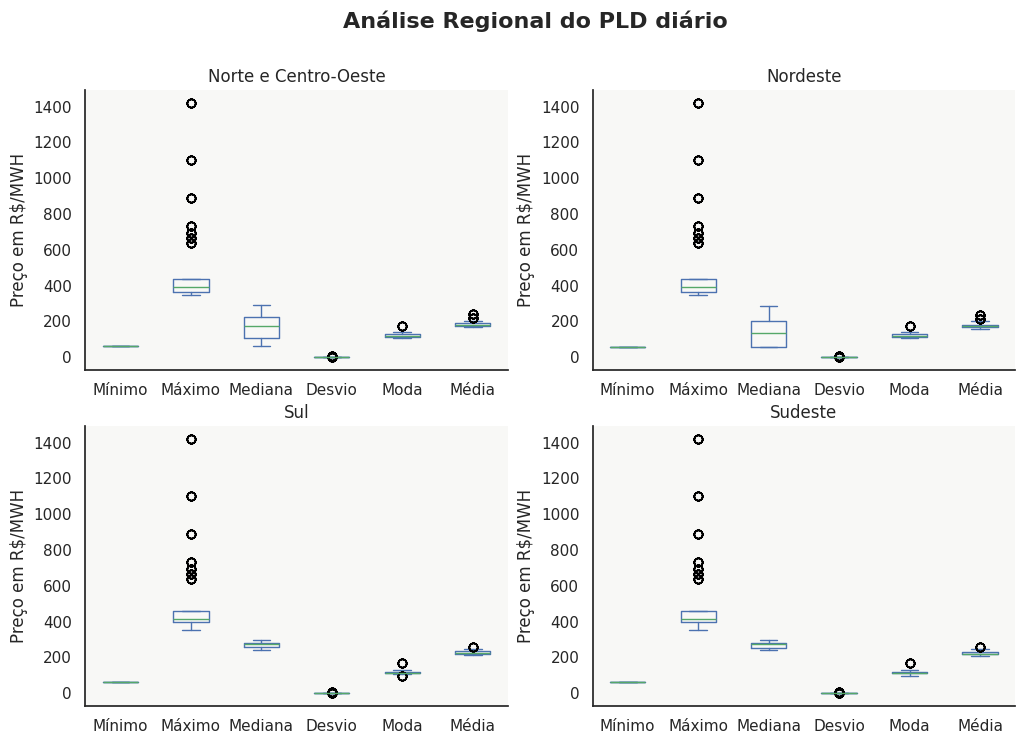

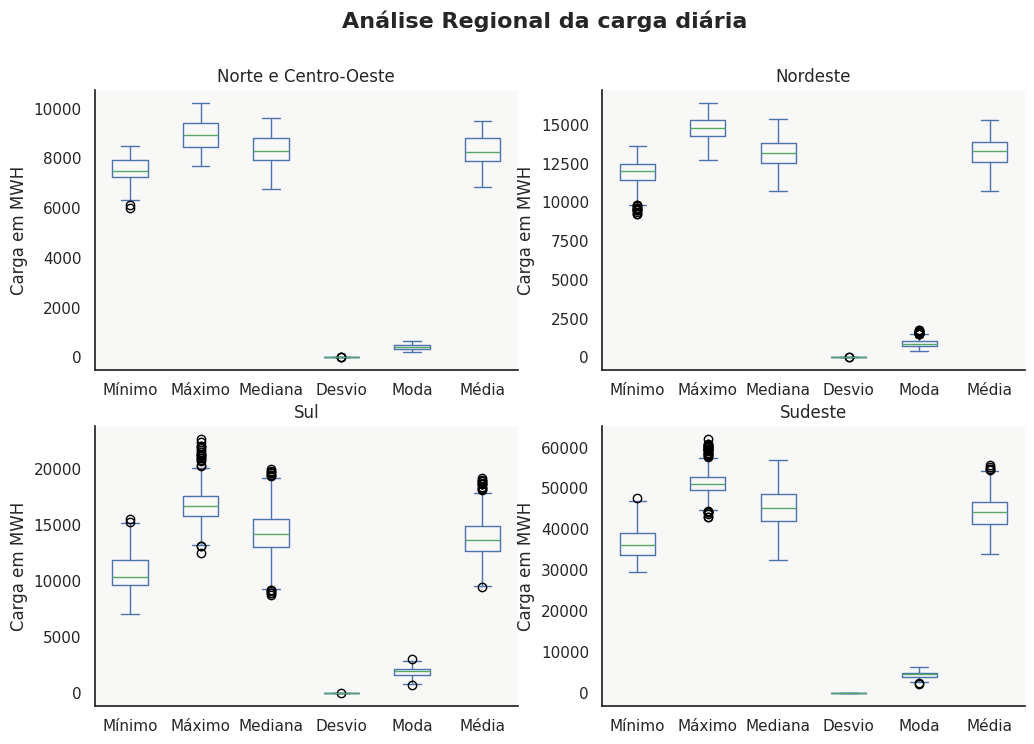

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('CURVA_CARGA_2025.csv', sep=';')
df = df.rename(columns={"id_subsistema":"Regioes S","nom_subsistema":"Regioes ","Data":"din_instante","val_cargaenergiahomwmed":"Carga"})
dfo = pd.read_csv('CURVA_CARGA_2025.csv', sep=';')
dfo = dfo.rename(columns={"id_subsistema":"Regioes","nom_subsistema":"SUBMERCADO","din_instante":"Data","val_cargaenergiahomwmed":"Carga"})
dfo['Data'] = pd.to_datetime(dfo['Data'])

dfo["Mes"] = dfo["Data"].dt.month
dfo["DIA"] = dfo["Data"].dt.day
dfo["HORA"] = dfo["Data"].dt.hour

dfo2 = pd.read_csv('pld_horario_2025.csv', sep=';')
df = pd.merge(dfo, dfo2, on=['SUBMERCADO', 'DIA', 'HORA'], how='inner')
df['Custos_Milhoes'] = (df['Carga'] * df['PLD_HORA']) / 1e6


estatistica_dia_pld_group = df[["DIA", "Mes", "Regioes" , "PLD_HORA", "Carga"]].groupby(["Mes", "DIA", "Regioes"])
estatistica_dia_pld= estatistica_dia_pld_group.agg({
  "PLD_HORA": ["min", "max", "median", "skew", "std", "mean"
               ]
})["PLD_HORA"]

estatistica_dia_carga_group = df[["DIA", "Mes", "Regioes", "PLD_HORA", "Carga"]].groupby(["Mes", "DIA", "Regioes"])
estatistica_dia_carga= estatistica_dia_pld_group.agg({
  "Carga": ["min", "max", "median", "skew", "std", "mean"
            ]
})["Carga"]
estatistica_dia_carga = estatistica_dia_carga.rename(columns={
  "max":"Máximo","min":"Mínimo","std":"Moda","mean":"Média","median":"Mediana", "skew":"Desvio"})

estatistica_dia_pld = estatistica_dia_pld.rename(columns={
  "max":"Máximo","min":"Mínimo","std":"Moda","mean":"Média","median":"Mediana", "skew":"Desvio",})

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes_flat = axes.flatten()

regioes = ["Norte e Centro-Oeste", "Nordeste", "Sul", "Sudeste"]

for i, reg in enumerate(["N", "NE", "S", "SE"]):
  ax = estatistica_dia_pld.loc[:, :, reg].plot.box(figsize=(12, 8), ax=axes_flat[i])
  ax.set_ylabel("Preço em R$/MWH")
  ax.set_title(regioes[i])
fig.suptitle("Análise Regional do PLD diário", fontsize=16, fontweight='bold')
plt.show()

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes_flat = axes.flatten()

for i, reg in enumerate(["N", "NE", "S", "SE"]):
  ax = estatistica_dia_carga.loc[:, :, reg].plot.box(figsize=(12, 8), ax=axes_flat[i])
  ax.set_ylabel("Carga em MWH")
  ax.set_title(regioes[i])
fig.suptitle("Análise Regional da carga diária", fontsize=16, fontweight='bold')
plt.show()



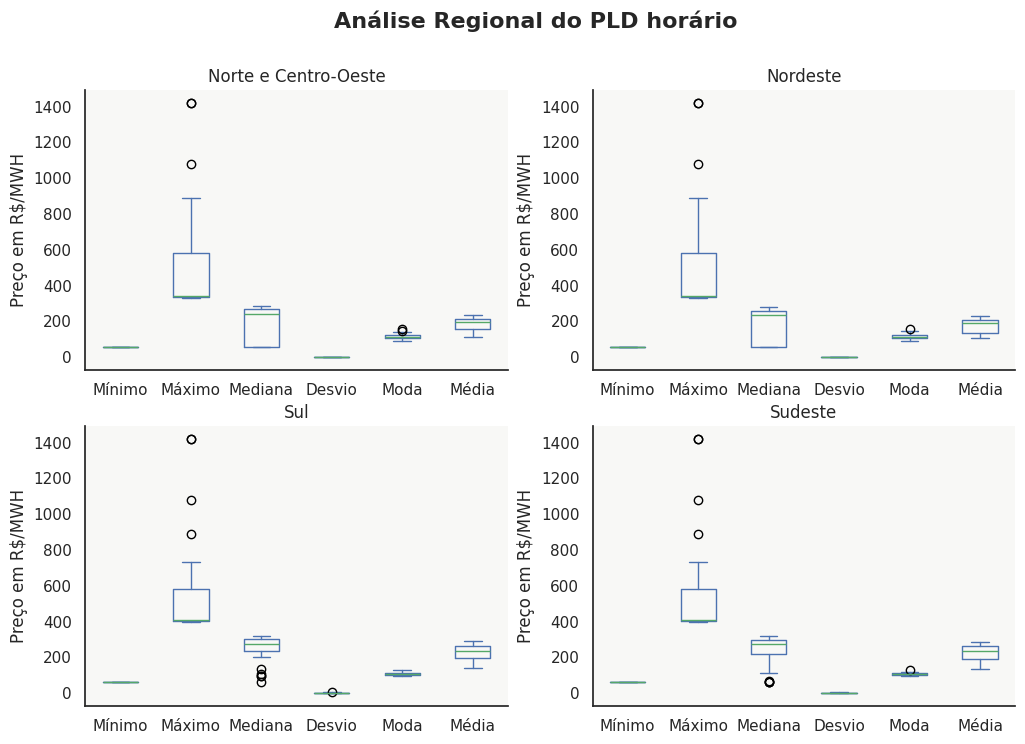

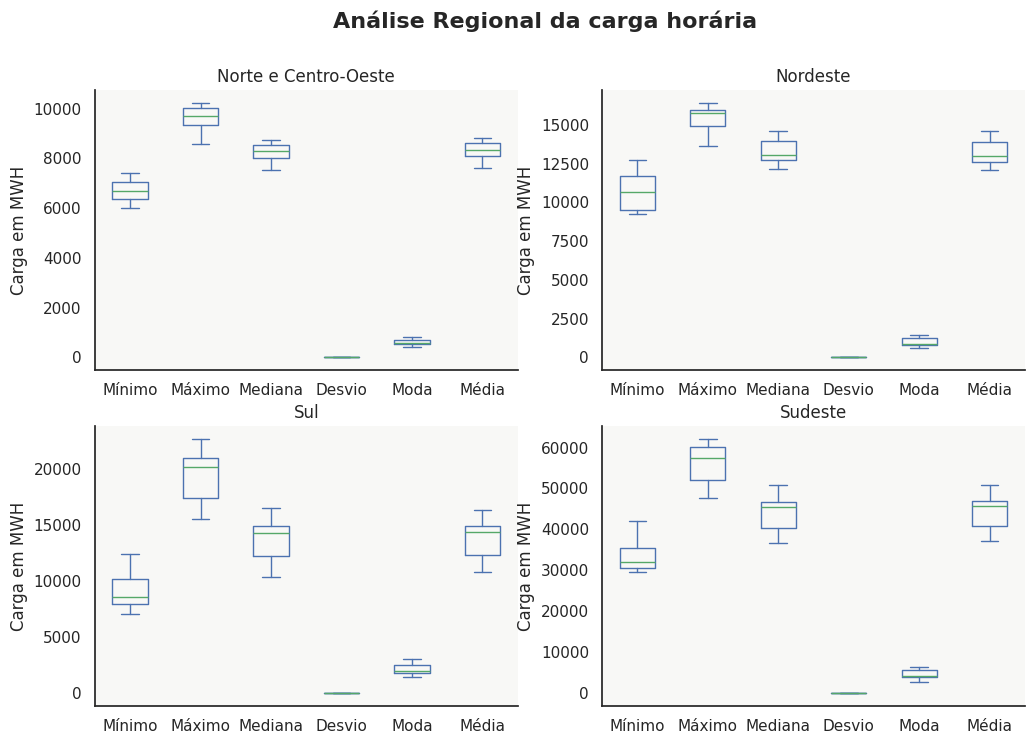

In [35]:
estatistica_hora_pld_group = df[["HORA", "Regioes" , "PLD_HORA", "Carga"]].groupby(["HORA", "Regioes"])
estatistica_hora_pld= estatistica_hora_pld_group.agg({
  "PLD_HORA": ["min", "max", "median", "skew", "std", "mean"
               ]
})["PLD_HORA"]

estatistica_hora_carga_group = df[["HORA", "Regioes", "PLD_HORA", "Carga"]].groupby(["HORA", "Regioes"])
estatistica_hora_carga= estatistica_hora_pld_group.agg({
  "Carga": ["min", "max", "median", "skew", "std", "mean"
            ]
})["Carga"]
estatistica_hora_carga = estatistica_hora_carga.rename(columns={
  "max":"Máximo","min":"Mínimo","std":"Moda","mean":"Média","median":"Mediana", "skew":"Desvio"})

estatistica_hora_pld = estatistica_hora_pld.rename(columns={
  "max":"Máximo","min":"Mínimo","std":"Moda","mean":"Média","median":"Mediana", "skew":"Desvio"})

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes_flat = axes.flatten()

regioes = ["Norte e Centro-Oeste", "Nordeste", "Sul", "Sudeste"]

for i, reg in enumerate(["N", "NE", "S", "SE"]):
  ax = estatistica_hora_pld.xs(reg, level="Regioes")
  ax = ax.plot.box(figsize=(12, 8), ax=axes_flat[i])
  ax.set_ylabel("Preço em R$/MWH")
  ax.set_title(regioes[i])
fig.suptitle("Análise Regional do PLD horário", fontsize=16, fontweight='bold')
plt.show()

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes_flat = axes.flatten()

for i, reg in enumerate(["N", "NE", "S", "SE"]):
  ax = estatistica_hora_carga.xs(reg, level="Regioes")
  ax = ax.plot.box(figsize=(12, 8), ax=axes_flat[i])
  ax.set_ylabel("Carga em MWH")
  ax.set_title(regioes[i])
fig.suptitle("Análise Regional da carga horária", fontsize=16, fontweight='bold')
plt.show()

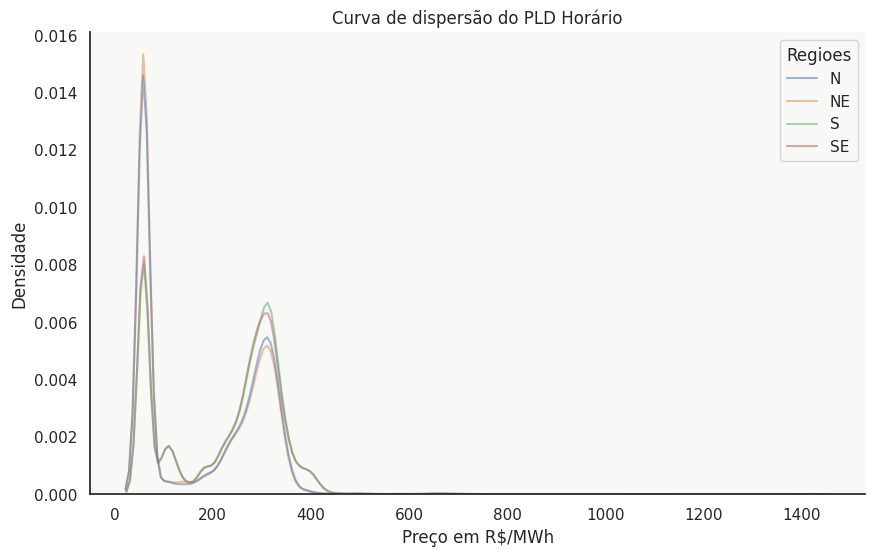

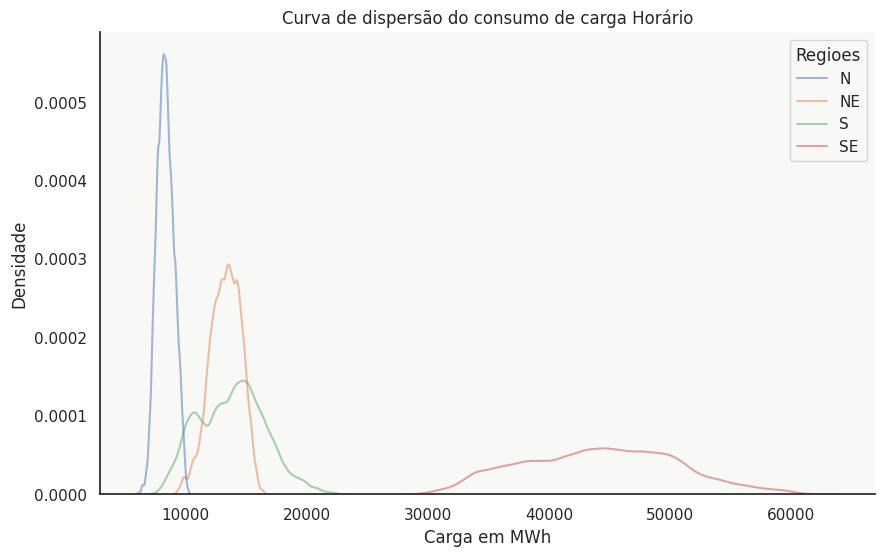

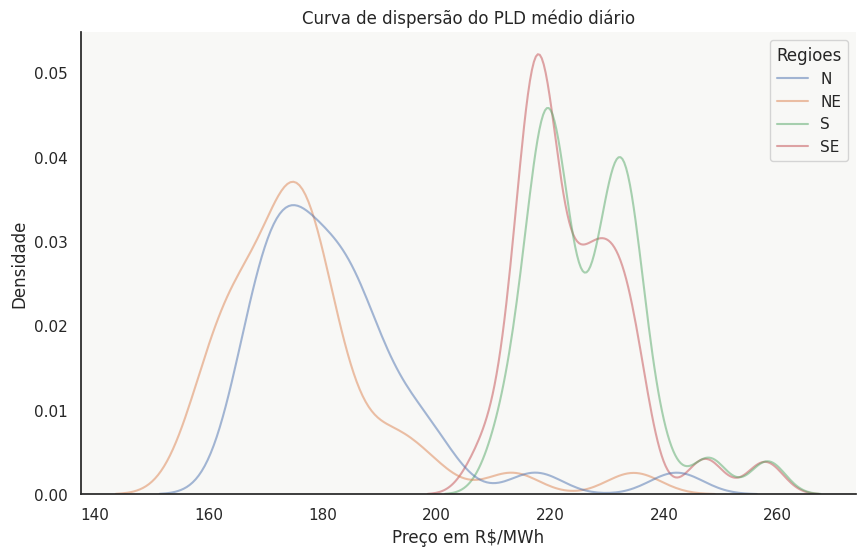

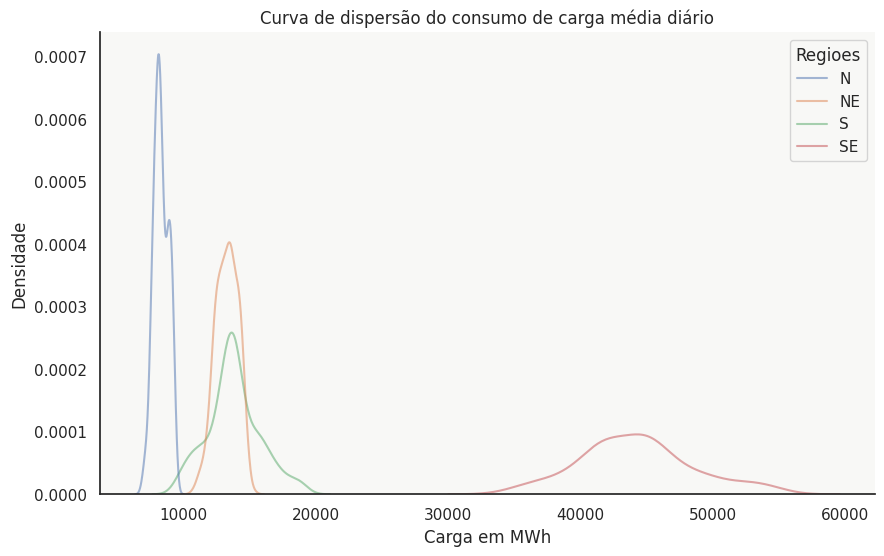

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Plot for PLD_HORA
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="PLD_HORA",
            hue="Regioes", fill=False,       # Preenche a área sob a curva
            alpha=0.5, common_norm=False)

plt.title("Curva de dispersão do PLD Horário")
plt.xlabel("Preço em R$/MWh")
plt.ylabel("Densidade")
# Seaborn handles the legend automatically based on 'hue'
plt.show()

# 2. Plot for Carga
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="Carga",
            hue="Regioes", fill=False,       # Preenche a área sob a curva
            alpha=0.5, common_norm=False)

plt.title("Curva de dispersão do consumo de carga Horário")
plt.xlabel("Carga em MWh")
plt.ylabel("Densidade")
plt.show()



plt.figure(figsize=(10, 6))
sns.kdeplot(data=estatistica_dia_pld, x="Média",
            hue="Regioes", fill=False,       # Preenche a área sob a curva
            alpha=0.5, common_norm=False)

plt.title("Curva de dispersão do PLD médio diário")
plt.xlabel("Preço em R$/MWh")
plt.ylabel("Densidade")
# Seaborn handles the legend automatically based on 'hue'
plt.show()

# 2. Plot for Carga
plt.figure(figsize=(10, 6))
sns.kdeplot(data=estatistica_dia_carga, x="Média",
            hue="Regioes", fill=False,       # Preenche a área sob a curva
            alpha=0.5, common_norm=False)

plt.title("Curva de dispersão do consumo de carga média diário")
plt.xlabel("Carga em MWh")
plt.ylabel("Densidade")
plt.show()

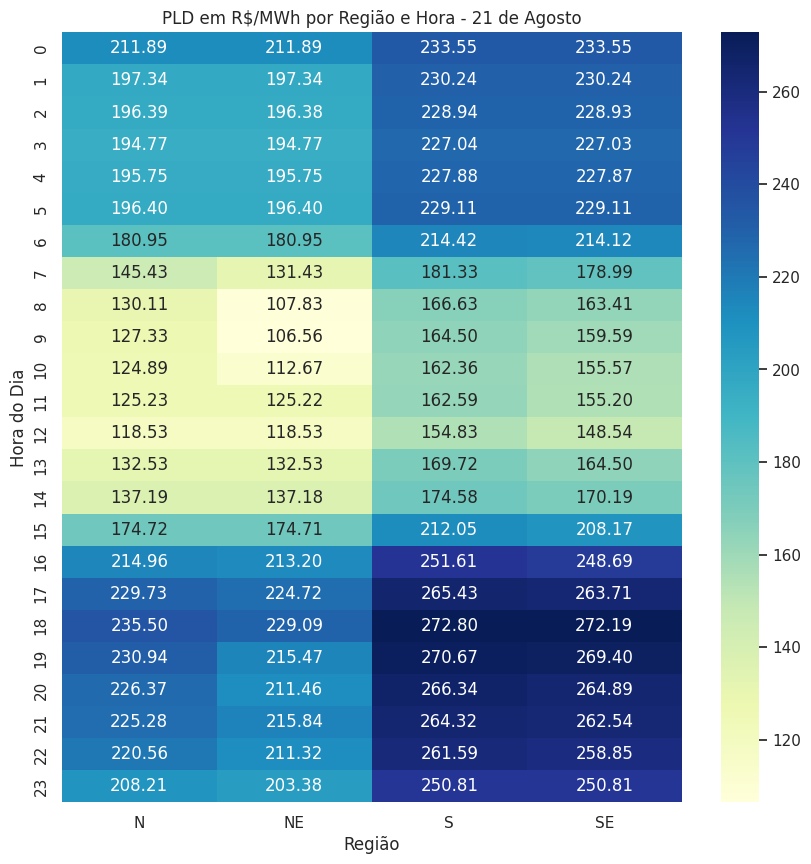

In [37]:
df_vinte_um = df[(df['DIA'] == 21) & (df['Mes'] == 8)]

matrix_pld = df_vinte_um.pivot_table(index='HORA', columns='Regioes', values='PLD_HORA')

plt.figure(figsize=(10, 10))
sns.heatmap(matrix_pld, annot=True, cmap="YlGnBu", fmt=".2f")

plt.title("PLD em R$/MWh por Região e Hora - 21 de Agosto")
plt.ylabel("Hora do Dia")
plt.xlabel("Região")
plt.show()

### Glossário de Variáveis

A seguir, uma tabela detalhada das variáveis utilizadas e criadas ao longo da análise, suas descrições e unidades correspondentes:

| Variável        | Descrição                                         | Unidade                 |
|:----------------|:--------------------------------------------------|:------------------------|
| `Regioes` / `SUBMERCADO` | Identificador do subsistema elétrico no Brasil (Norte, Nordeste, Sul, Sudeste). | N/A (Categórica)        |
| `Regioes S`     | Código curto do subsistema elétrico (N, NE, S, SE). | N/A (Código)            |
| `din_instante` / `Data` | Instante de tempo da leitura de carga ou preço.     | datetime (YYYY-MM-DD HH:MM:SS) |
| `Carga`         | Valor da carga de energia homologada.             | MWmed (Megawatt médio)  |
| `Mes`           | Mês do ano extraído da coluna `Data`.             | Inteiro (1-12)          |
| `DIA`           | Dia do mês extraído da coluna `Data`.             | Inteiro (1-31)          |
| `HORA`          | Hora do dia extraído da coluna `Data`.            | Inteiro (0-23)          |
| `PLD_HORA`      | Preço de Liquidação das Diferenças (PLD) horário. | R$/MWh (Reais por Megawatt-hora) |
| `MES_REFERENCIA`| Mês de referência para os dados de PLD.          | String (YYYYMM)         |
| `Custos_Milhoes`| Custo total estimado (Carga * PLD_HORA).          | Milhões de R$ (Reais)   |
| `soma`          | Potência líquida consumida total por região.      | GWh/h (Gigawatt-hora por hora) |
| `media`         | Consumo médio por região ou por mês.              | MWh/h (Megawatt-hora por hora) |
| `PLD_MEDIO`     | Preço de Liquidação das Diferenças (PLD) médio mensal por subsistema. | R$/MWh (Reais por Megawatt-hora) |
| `ROTULO`        | Rótulo formatado do mês de referência.            | String (ex: "Jan/25")   |